<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/ESAA_YB_WEEK13_study_0615.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Information

##Import the Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

In [2]:
data = pd.read_csv('Mall_Customers.csv')
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


##Data Info

In [3]:
data.shape

(200, 5)

In [4]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


<Axes: >

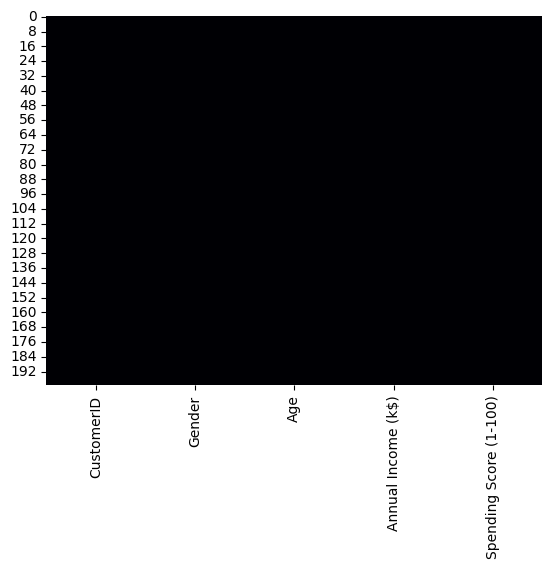

In [6]:
sns.heatmap(data.isnull(), cmap='magma', cbar=False)

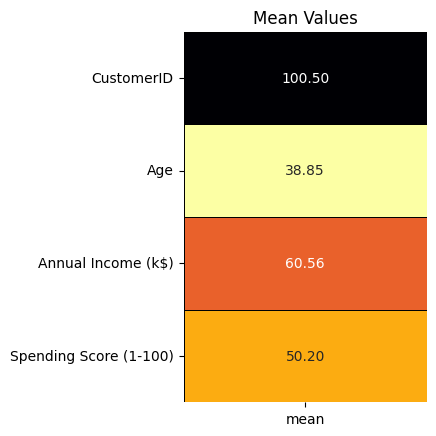

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))

plt.subplot(1,1,1)
sns.heatmap(data.describe().T[['mean']], cmap='inferno_r', annot=True,
            fmt='.2f', linecolor='black', linewidths=0.4, cbar=False)
plt.title('Mean Values')

fig.tight_layout(pad=3)

* 고객의 평균 연령은 **38.85세**로, 주 고객층은 **30대 후반에 해당함**.
* 고객의 평균 연소득은 **60.56천 달러**로, **2018년 미국 중위소득(63천 달러)에 근접함**.
* 고객의 평균 소비 점수는 **50.20점**으로, **전반적으로 중간 수준의 소비 성향을 보임**.

# Exploratory Data Analysis

##Dividing features into Numerical and Categorical

In [8]:
col = list(data.columns)
categorical_features = []
numerical_features = []
for i in col:
  if len(data[i].unique()) > 6:
    numerical_features.append(i)
  else:
    categorical_features.append(i)

print('Categorical Features: ', *categorical_features)
print('Numerical Features: ', *numerical_features)

Categorical Features:  Gender
Numerical Features:  CustomerID Age Annual Income (k$) Spending Score (1-100)


* 범주형 변수는 **고유값이 6개 미만인 속성**, 그 외는 **수치형 변수로 정의함**.
* 일반적으로는 **데이터 타입을 기준으로 구분**하며, 정수형은 수치형 변수, 문자열형은 범주형 변수로 분류함.
* 본 데이터셋은 변수 수가 적어 **수동으로 변수 유형을 확인하고 분류할 수 있음**.

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1 = data.copy(deep=True)

df1['Gender'] = le.fit_transform(df1['Gender'])

print('Label Encoder Transformation')
print(df1['Gender'].unique(), ' = ',
      le.inverse_transform(df1['Gender'].unique()))

Label Encoder Transformation
[1 0]  =  ['Male' 'Female']


* 원본 데이터셋의 깊은 복사본(deep copy)을 생성하고, `Gender` 변수에 레이블 인코딩(Label Encoding)을 적용함.
* 깊은 복사본을 사용함으로써 **원본 데이터셋의 수정 사항이 복사본에 영향을 미치지 않도록 함**.
* 시각화 및 모델링에 활용하기 위해 **`Gender`를 수치형 값으로 변환한 복사본 데이터셋을 사용함**.


##Distribution of Categorical and Numerical Features

/tmp/ipykernel_11848/1457418991.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[categorical_features[i]], kde_kws={'bw': 1})
/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:2496: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=1`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)
/tmp/ipykernel_11848/1457418991.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to u

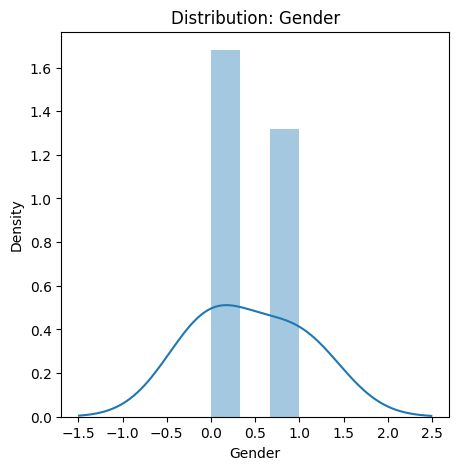

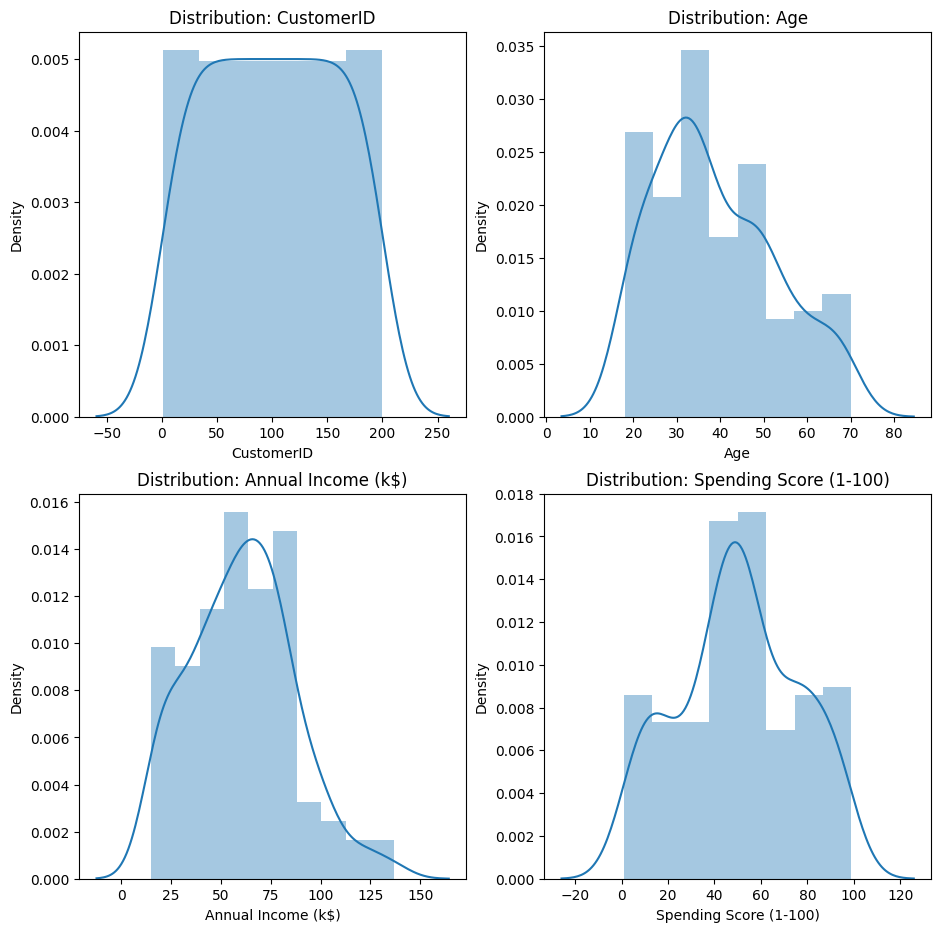

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))
for i in range(len(categorical_features)):
  plt.subplot(1,1,i+1)
  sns.distplot(df1[categorical_features[i]], kde_kws={'bw': 1})
  title = 'Distribution: ' + categorical_features[i]
  plt.title(title)

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(11,11))
for i in range(len(numerical_features)):
  plt.subplot(2,2,i+1)
  sns.distplot(data[numerical_features[i]],)
  title = 'Distribution: ' + numerical_features[i]
  plt.title(title)
plt.show()

* 유일한 범주형 변수인 **Gender는 정규분포에 가까운 분포를 보임**.
* **Age**와 **Annual Income**는 **양의 왜도(우측 치우침)를 가진 분포를 보임**.
* **Spending Score**는 주식 차트의 **헤드 앤 숄더(Head and Shoulders) 패턴과 유사한 형태를 보이며**, 20과 80 부근에 어깨(Shoulder), 40~60 구간에 머리(Head)가 형성됨.
* **CustomerID는 고객 식별용 번호에 불과하므로 분석에서 제외함**.


In [11]:
numerical_features.remove('CustomerID')

##Categorical Features

/tmp/ipykernel_11848/69292850.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Gender', data = df1,palette = colors, edgecolor = 'black')
/tmp/ipykernel_11848/69292850.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female', 'Male'])


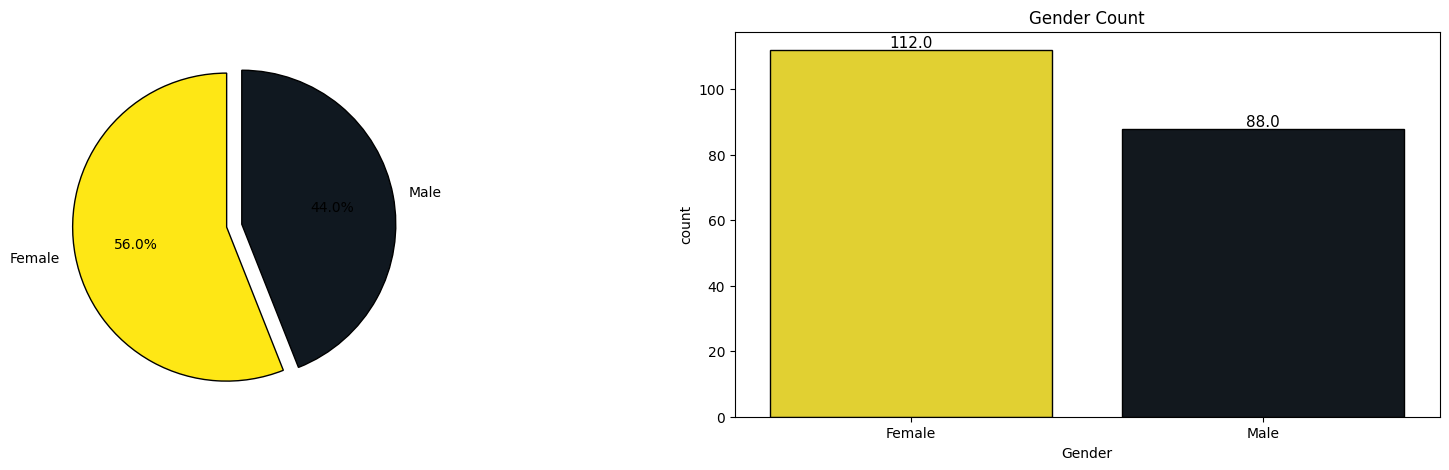

In [12]:
l = list(data['Gender'].value_counts())
circle = [l[0] / len(l) * 100, l[1] / len(l) * 100]
colors = ['#FEE715','#101820']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,5))

plt.subplot(1,2,1)
plt.pie(circle,labels = ['Female','Male'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),
        colors = colors, wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})

plt.subplot(1,2,2)
ax = sns.countplot(x='Gender', data = df1,palette = colors, edgecolor = 'black')
for rect in ax.patches:
  ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.75,
          rect.get_height(), horizontalalignment='center', fontsize=11)
plt.title('Gender Count')
ax.set_xticklabels(['Female', 'Male'])
plt.show()

##Numerical Features vs Categorical Features

/tmp/ipykernel_11848/4190829715.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Gender', y=numerical_features[i], palette=colors, data=df1)
/tmp/ipykernel_11848/4190829715.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female', 'Male'])
/tmp/ipykernel_11848/4190829715.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='Gender', y=numerical_features[i], palette=colors, data=df1)
/tmp/ipykernel_11848/4190829715.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xtickla

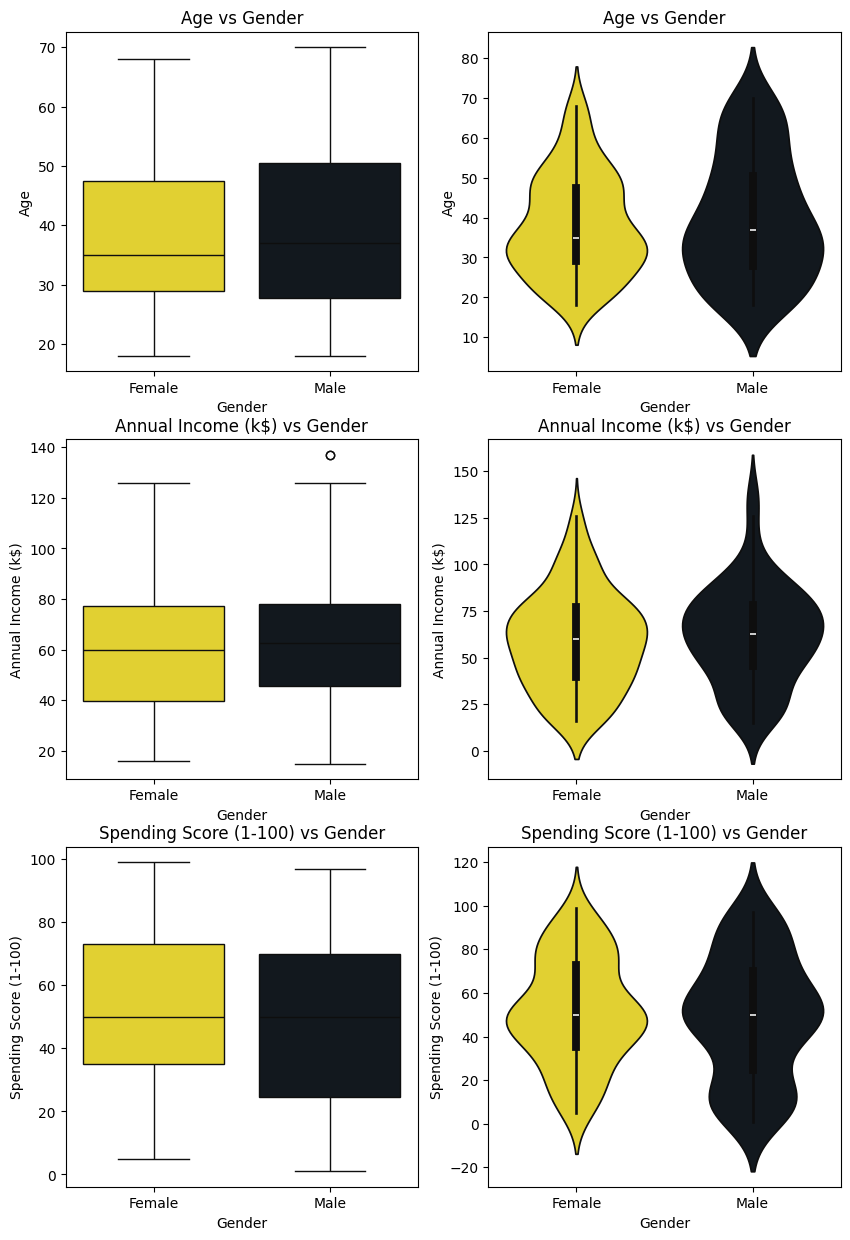

In [13]:
fig = plt.subplots(nrows=3, ncols=2, figsize=(10, 15))
for i in range(len(numerical_features)):
  plt.subplot(3, 2, (i*2) + 1)
  ax = sns.boxplot(x='Gender', y=numerical_features[i], palette=colors, data=df1)
  ax.set_xticklabels(['Female', 'Male'])
  title = numerical_features[i] + ' vs Gender'
  plt.title(title)

  plt.subplot(3, 2, (i*2) + 2)
  ax = sns.violinplot(x='Gender', y=numerical_features[i], palette=colors, data=df1)
  ax.set_xticklabels(['Female', 'Male'])
  title = numerical_features[i] + ' vs Gender'
  plt.title(title)

* 여성 고객의 연령은 **30세에서 50세 미만**, 남성 고객의 연령은 **30세 미만에서 50세까지** 분포함.
* 두 성별 모두 **30~35세 구간에 고객이 집중되는 경향**을 보이며, 남성 고객의 **중위 연령이 여성보다 약간 높음**.
* 여성 고객의 연소득은 **40k달러부터 시작**하는 반면, 남성 고객은 이보다 높은 수준에서 분포가 시작됨.
* 두 성별의 **중위 연소득은 약 60k달러로 유사**하며, 남성 고객의 소득 분포는 정점 부근에서 더 급격히 감소하고 일부 이상치를 포함함.
* 두 성별의 **중위 소비 점수는 동일**하지만, 여성은 40점 미만, 남성은 20점 초반부터 분포가 시작됨.
* 두 성별 모두 **중위 소비 점수 부근에 고객이 집중**되어 있으며, 특히 여성 고객에서 이러한 경향이 두드러짐. 또한 남성 고객은 **0~20점 구간에도 의미 있는 집중 현상**을 보임.


##Numerical Features vs Numerical Features w.r.t Categorical Feature

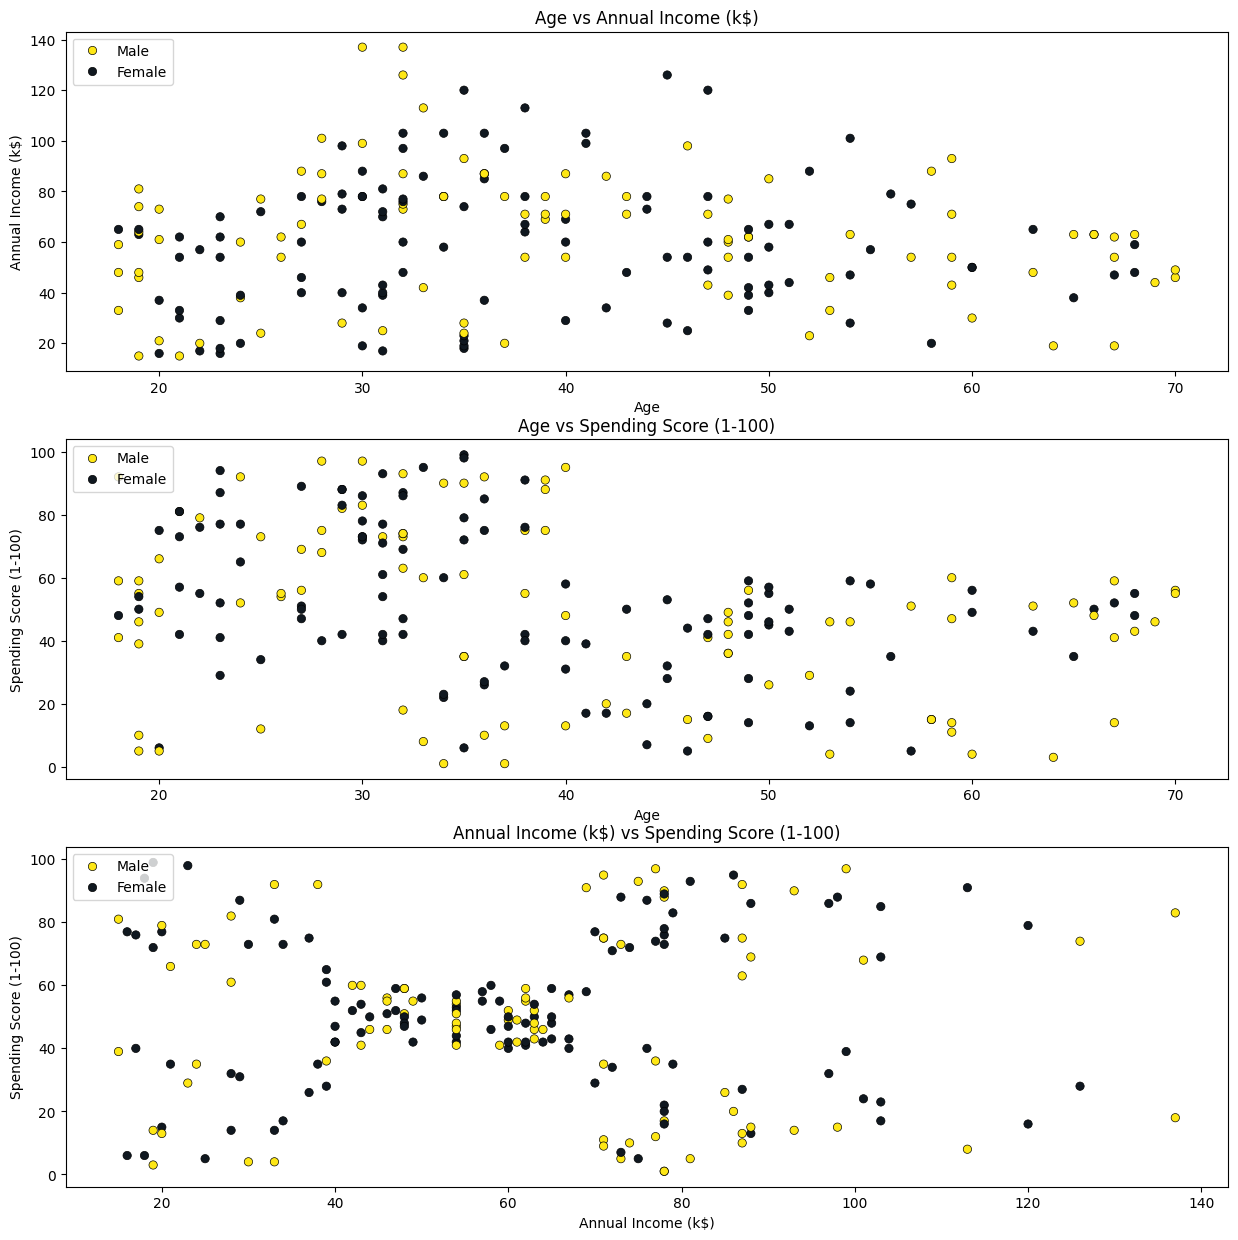

In [14]:
a = 0
fig,ax = plt.subplots(nrows = 3,ncols = 1,figsize = (15,15))
for i in range(len(numerical_features) - 1):
    for j in range(len(numerical_features)):
        if i != j and j > i:
            a += 1
            plt.subplot(3,1,a)
            sns.scatterplot(x = numerical_features[i],y = numerical_features[j],data = data,
                            hue = 'Gender',palette = colors,edgecolor = 'black');
            plt.legend(loc = 'upper left',)
            title = numerical_features[i] + ' vs ' + numerical_features[j]
            plt.title(title)

* **Annual Income**는 모든 연령대에 걸쳐 분포하여, **Gender는 소득 분포를 설명하는 데 큰 영향을 주지 않음**.
* **Spending Score (1–100)** 기준으로는 **20~30세 고객층이 매우 높은 소비 성향**을 보임.
* **30~40세 고객층은 높은 소비 성향과 낮은 소비 성향이 모두 나타나는 양극화된 특징**을 보임.
* **40~70세 고객층은 전반적으로 낮은 소비 점수**를 보이는 경향이 있음.
* **Annual Income와 Spending Score (1–100)의 관계에서는 뚜렷한 5개의 고객 그룹이 관찰됨**.
* 소득이 **0 ~ 40k$인 고객은 소비 점수 0 ~ 40과 60 ~ 100 구간으로 나뉘는 두 개의 그룹**을 형성함.
* 소득이 **40 ~ 70k달러인 고객은 소비 점수 40 ~ 60 구간에 집중된 중간 그룹**을 형성함.
* 소득이 **70 ~ 140k달러인 고객은 소비 점수 0 ~ 40과 60 ~ 100구간으로 다시 나뉘며, 두 개의 극단적인 소비 그룹**을 형성함.



#Summary of EDA

* 쇼핑몰 고객은 **여성 고객이 남성 고객보다 다소 많으며**, 성별은 다른 변수들과 비교했을 때 비교적 균등하게 분포함.
* 고객 연령은 **20 ~ 30세, 30 ~ 40세, 40~70세의 세 그룹으로 구분할 수 있음**.
* 남녀 모두 **중위 연소득은 약 60k달러**이며, 소득 수준은 **0 ~ 40k달러, 40 ~ 70k달러, 70 ~ 140k달러의 세 구간으로 분류할 수 있음**.
* 여성 고객의 **소비 점수(Spending Score)가 남성보다 상대적으로 높게 나타남**.
* 소비 점수는 **0 ~ 40, 40 ~ 60, 60 ~ 100의 세 그룹으로 구분할 수 있음**.
* 연령, 소득, 소비 점수를 조합하여 **고객을 세분화(Segmentation)할 수 있으며, 이를 통해 고객 특성에 맞춘 맞춤형 마케팅 및 서비스 제공이 가능함**.


#Feature Engineering


##Correlation Matrix

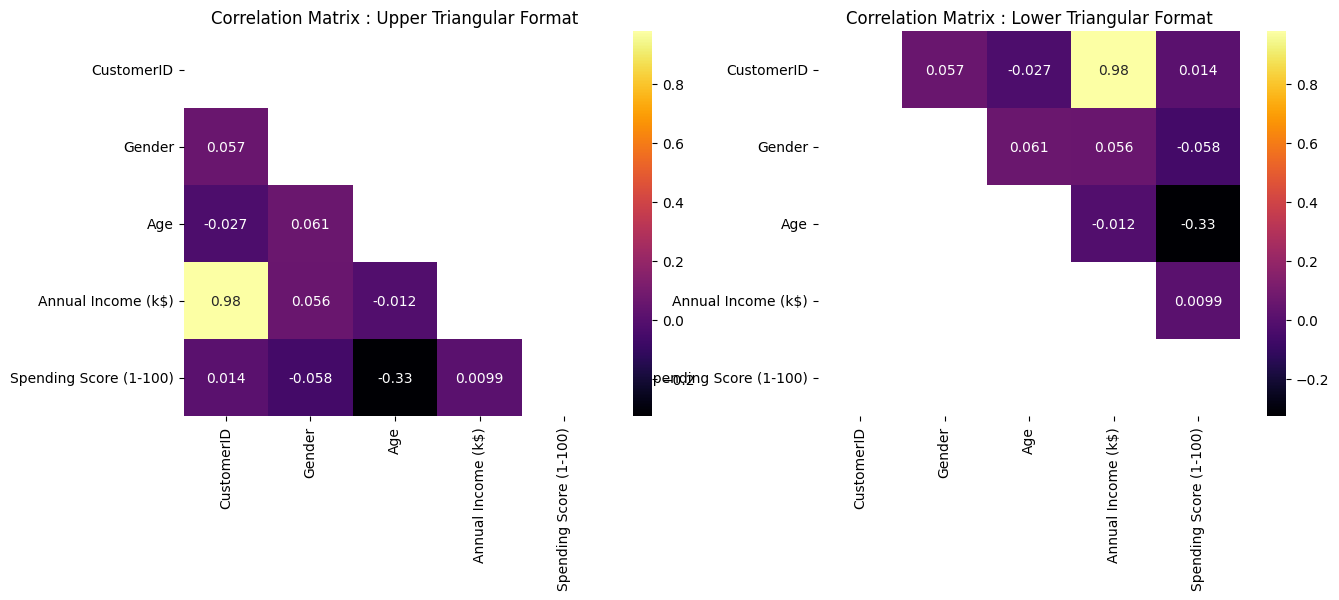

In [15]:
ut = np.triu(df1.corr())
lt = np.tril(df1.corr())

fig,ax = plt.subplots(nrows = 1, ncols = 2,figsize = (15,5))
plt.subplot(1,2,1)
sns.heatmap(df1.corr(),cmap = 'inferno',annot = True,cbar = 'True',mask = ut);
plt.title('Correlation Matrix : Upper Triangular Format');

plt.subplot(1,2,2)
sns.heatmap(df1.corr(),cmap = 'inferno',annot = True,cbar = 'True',mask = lt);
plt.title('Correlation Matrix : Lower Triangular Format');

df1.drop(columns = 'CustomerID',inplace = True)

* 두 상관관계 행렬은 동일한 정보를 나타내며, **시각화 목적을 위해 서로 다른 형태로 표현한 것임**.
* 이러한 시각화 기법은 **변수가 많은 데이터셋에서 변수 간 관계를 효율적으로 파악하는 데 활용할 수 있음**.
* **CustomerID는 고객이 연소득 순으로 정렬되어 있어 Annual Income (k$)와 높은 양의 상관관계를 보이지만**, 식별자 역할만 수행하므로 모델링에서는 제외함.
* **Gender는 다른 변수들과 뚜렷한 상관관계를 보이지 않으며**, 전반적으로 중립적인 특성을 나타냄.
* **Spending Score (1–100)와 Age는 음의 상관관계를 보이며**, 한 변수의 값이 증가할수록 다른 변수의 값은 감소하는 경향이 있음.
* 이러한 결과는 **탐색적 데이터 분석(EDA)에서 확인된 패턴을 상관관계 분석이 뒷받침하는 것임**.
* 이후에는 다양한 변수 조합을 활용하여 **고객 세분화(Segmentation) 모델링을 수행하고 고객군을 구분할 예정임**.


##Data Scaling

* 머신러닝 모델은 특징 값의 **단위나 의미를 이해하지 못하고 단순한 숫자로만 처리하므로, 데이터 스케일링이 필요함**.
* 데이터 스케일링 방법에는 **정규화(Normalization)와 표준화(Standardization) 두 가지가 있음**.
* 일반적으로 알고리즘은 데이터가 **정규분포를 따른다고 가정하는 경우가 많으며**, 이에 따라 분포 특성에 맞는 스케일링을 적용함.
* **정규화는 비정규분포 데이터를 처리할 때**, **표준화는 정규분포이지만 값의 범위 차이가 큰 경우**에 사용됨.
* 해당 데이터셋에서는 **Age, Annual Income (k$), Spending Score (1–100)에 정규화를 적용함**.
* **Gender 변수는 스케일링 대상에서 제외하고 그대로 유지함**.


In [16]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
mms = MinMaxScaler() # Normalization
ss = StandardScaler() # Standardization

# Label Encoding
df2 = df1.copy(deep=True)

# Normalization
df2['Age'] = mms.fit_transform(df2[['Age']])
df2['Annual Income (k$)'] = mms.fit_transform(df2[['Annual Income (k$)']])
df2['Spending Score (1-100)'] = mms.fit_transform(df2[['Spending Score (1-100)']])

* 모델 성능 비교를 위해 **원본 데이터셋과 정규화된 데이터셋 간의 차이를 강조하고자 함**.
* 이를 위해 **원본 데이터셋의 복사본을 생성한 후 해당 복사본에 정규화 변환을 적용함**.
* 이후에는 **모델링 단계로 진행하여 두 데이터셋 간 성능 차이를 비교 분석할 예정임**.


#Modeling

* 비지도학습(Unsupervised Learning)은 목표 변수(타깃)가 존재하지 않거나 알려지지 않은 문제를 다루는 학습 방식임.
* 의료 분야와 같이 원인을 알 수 없는 다양한 측정값이 존재하는 경우, **비지도학습을 통해 데이터 내 숨겨진 패턴을 발견할 수 있음**.
* 데이터 시각화는 이러한 패턴을 이해하는 데 도움을 주지만, **변수 수가 많고 데이터 규모가 커질수록 시각화만으로 분석하기 어려움**.
* 이를 해결하기 위해 **범주형 변수를 지원하지 않는 K-Means 클러스터링 알고리즘을 활용함**.
* K-Means는 데이터를 유사한 특성을 가진 여러 그룹(클러스터)으로 나누는 대표적인 비지도학습 알고리즘임.
* 알고리즘은 임의의 중심점(centroid)을 선택한 후, 각 데이터 포인트와의 거리를 계산하여 가장 가까운 중심점에 할당함.
* 이후 각 클러스터에 속한 데이터들의 평균값을 새로운 중심점으로 갱신하며, 중심점이 더 이상 크게 변하지 않을 때까지 이 과정을 반복함.
* **k 값은 생성할 클러스터의 개수를 의미하는 하이퍼파라미터임**.
* 최적의 k 값을 선택하기 위해 엘보우 기법(Elbow Method)과 실루엣 점수(Silhouette Score)를 활용함.
* 엘보우 기법은 **클러스터 내 제곱합 오차(Inertia)의 감소 추세를 분석하여 최적의 k 값을 찾는 방법임**.
* 실루엣 점수는 **클러스터 내부 응집도와 클러스터 간 분리도를 평가하여 군집 품질을 측정하는 방법임**.
* 이후에는 선정된 변수 조합을 이용하여 **K-Means 모델을 학습하고, 고객 세분화 결과를 시각화하여 분석할 예정임**.


쉽게 말하면, 이 단계는 **"정답 없이 고객들을 비슷한 특징끼리 자동으로 그룹화해보자"**는 의미임.

* 지금 데이터에는 "이 고객은 VIP", "이 고객은 일반 고객" 같은 **정답 라벨이 없음**.
* 그래서 비지도학습(K-Means)을 이용해 **나이, 소득, 소비 성향이 비슷한 고객들을 자동으로 묶음**.
* 예를 들어 다음과 같은 그룹이 만들어질 수 있음.

  * **고소득·고소비 고객** → VIP 고객
  * **고소득·저소비 고객** → 잠재 고객
  * **저소득·고소비 고객** → 할인 행사 선호 고객
  * **저소득·저소비 고객** → 일반 고객

K-Means는 이 그룹을 찾기 위해:

1. 임의로 그룹의 중심점을 정함.
2. 각 고객을 가장 가까운 중심점에 배정함.
3. 배정된 고객들의 평균 위치로 중심점을 다시 계산함.
4. 중심점이 더 이상 변하지 않을 때까지 반복함.

여기서 **k**는 "몇 개의 그룹으로 나눌 것인가?"를 의미함.

* k=3 → 고객을 3개 그룹으로 나눔.
* k=5 → 고객을 5개 그룹으로 나눔.

엘보우 기법과 실루엣 점수는 **"몇 개의 그룹으로 나누는 것이 가장 적절한가?"를 찾기 위한 방법**임.

결국 이 분석의 목표는 **쇼핑몰 고객을 여러 유형으로 세분화하여 고객별 맞춤 마케팅 전략을 수립하는 것임**. 예를 들어 고소득·고소비 고객에게는 VIP 혜택을, 저소득·고소비 고객에게는 할인 쿠폰을 제공할 수 있음.


In [17]:
# Dropping categorical feature
df1.drop(columns='Gender', inplace=True)
df2.drop(columns='Gender', inplace=True)

In [21]:
m1 = df1[['Age', 'Annual Income (k$)']].values # Original Dataset
m2 = df2[['Age', 'Annual Income (k$)']].values # Normalized Dataset

##Age - Annual Income
###Original Datasets

####Elbow Method & Silhouette Score Method

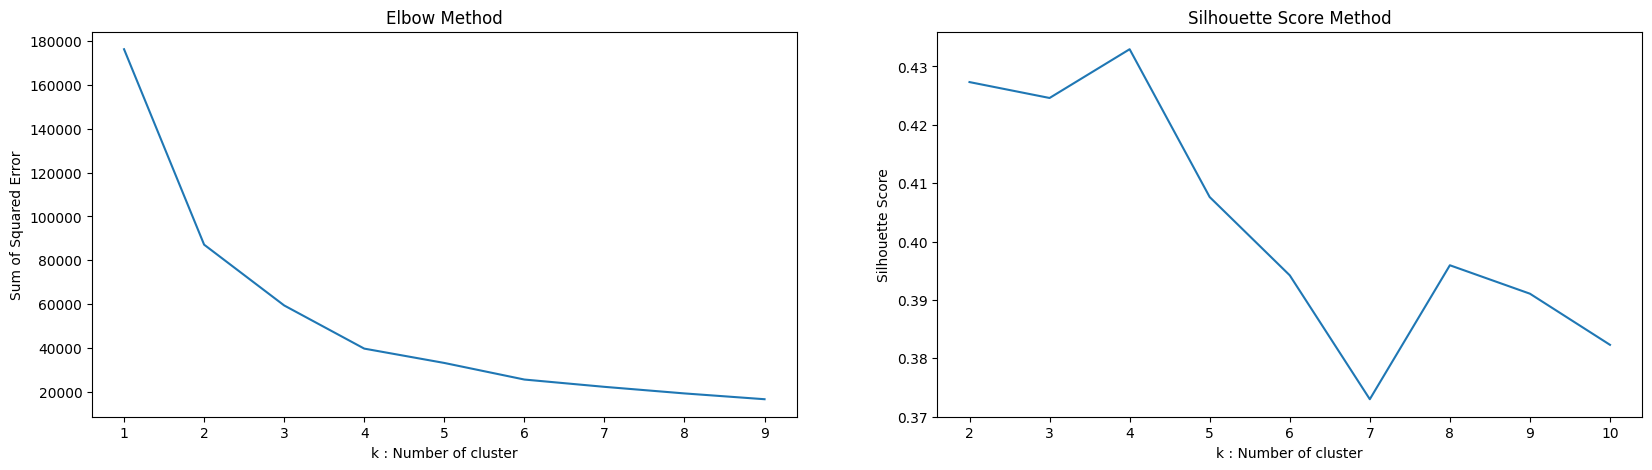

In [22]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

k: Clusters = 4 선택

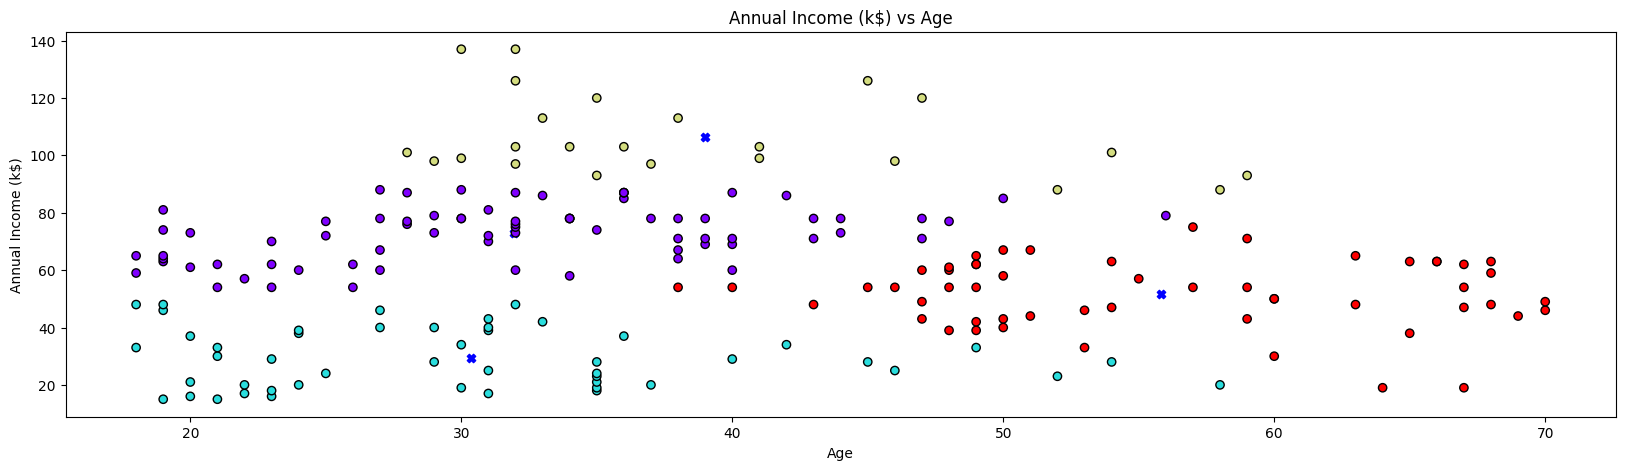

In [23]:
model = KMeans(n_clusters = 4,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Annual Income (k$)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

###Normalized Dataset
####Elbow Method & Silhouette Score Method

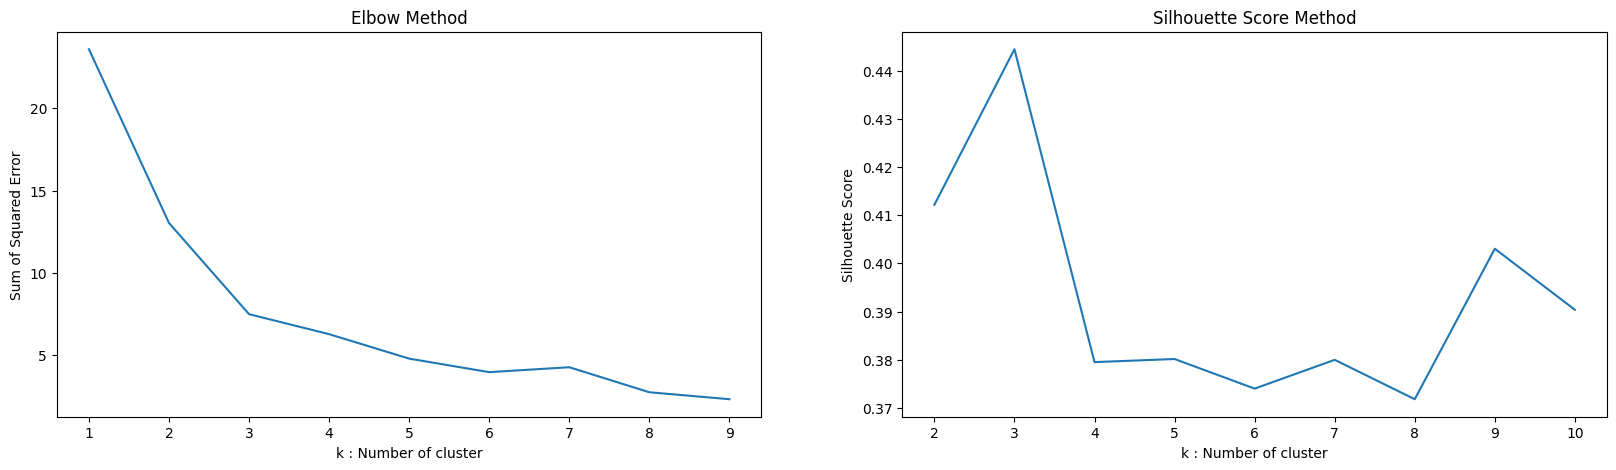

In [24]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

k: Clusters = 3 선택

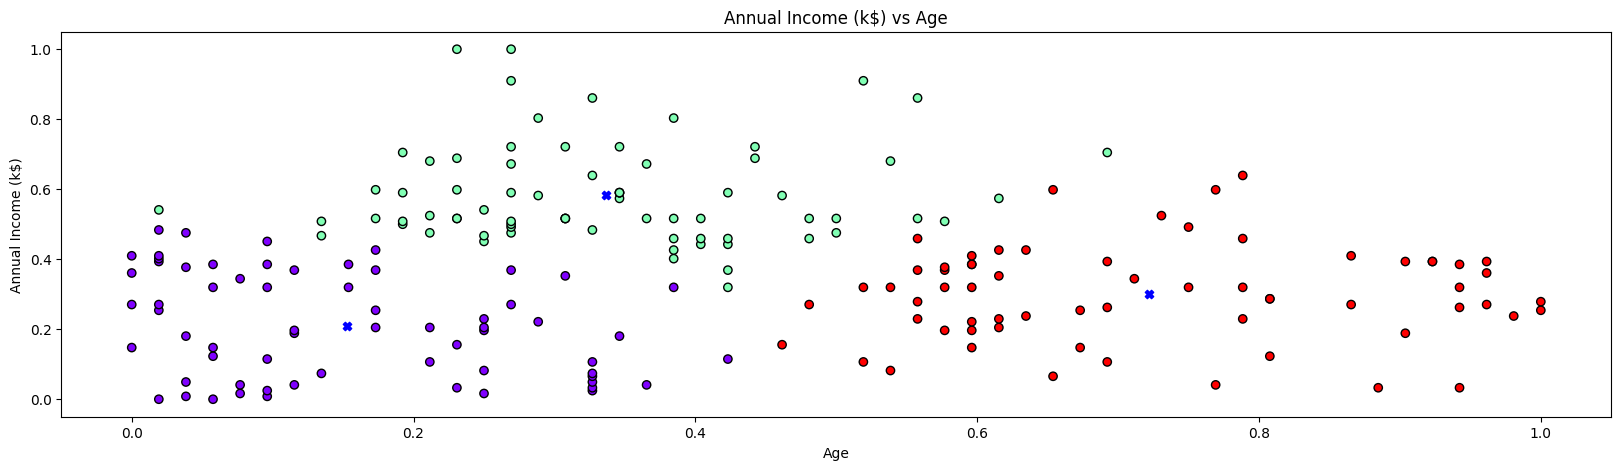

In [25]:
model = KMeans(n_clusters = 3,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Annual Income (k$)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

##Age - Spending Score (1-100)

In [32]:
m1 = df1[['Age','Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Age','Spending Score (1-100)']].values # Normalized Dataset

###Original Dataset
####Elbow Method & Silhouette Score Method

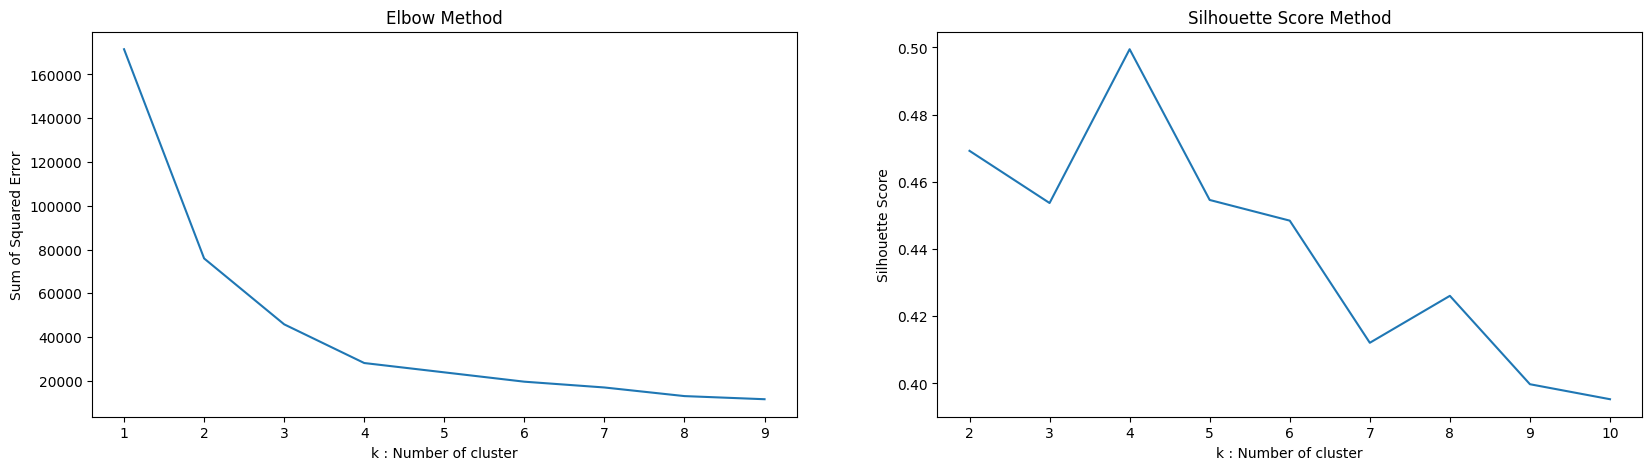

In [27]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

k: Clusters = 4 선택

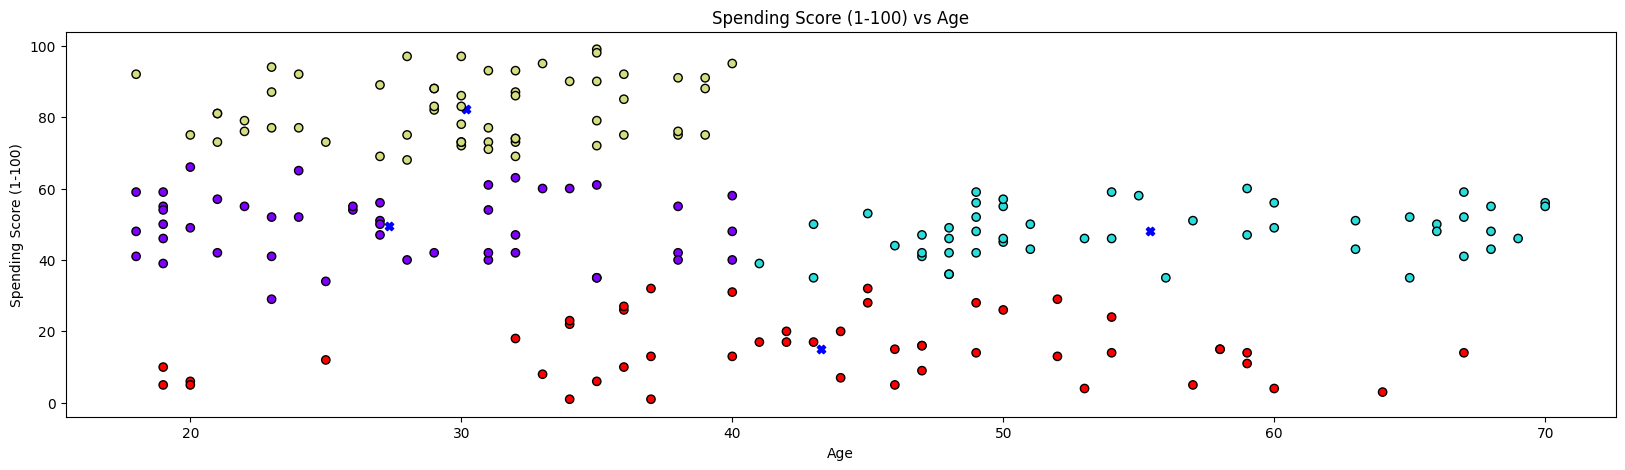

In [29]:
model = KMeans(n_clusters = 4,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

###Normalized Dataset
####Elbow Method & Silhouette Score Method

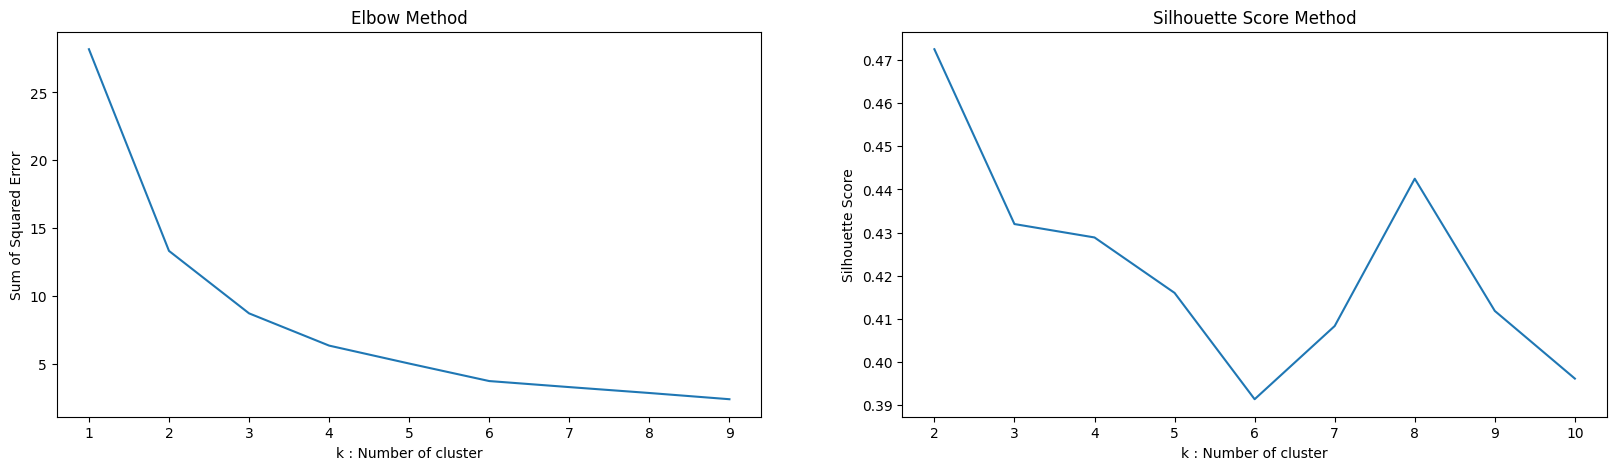

In [33]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

k: Clusters = 6 선택

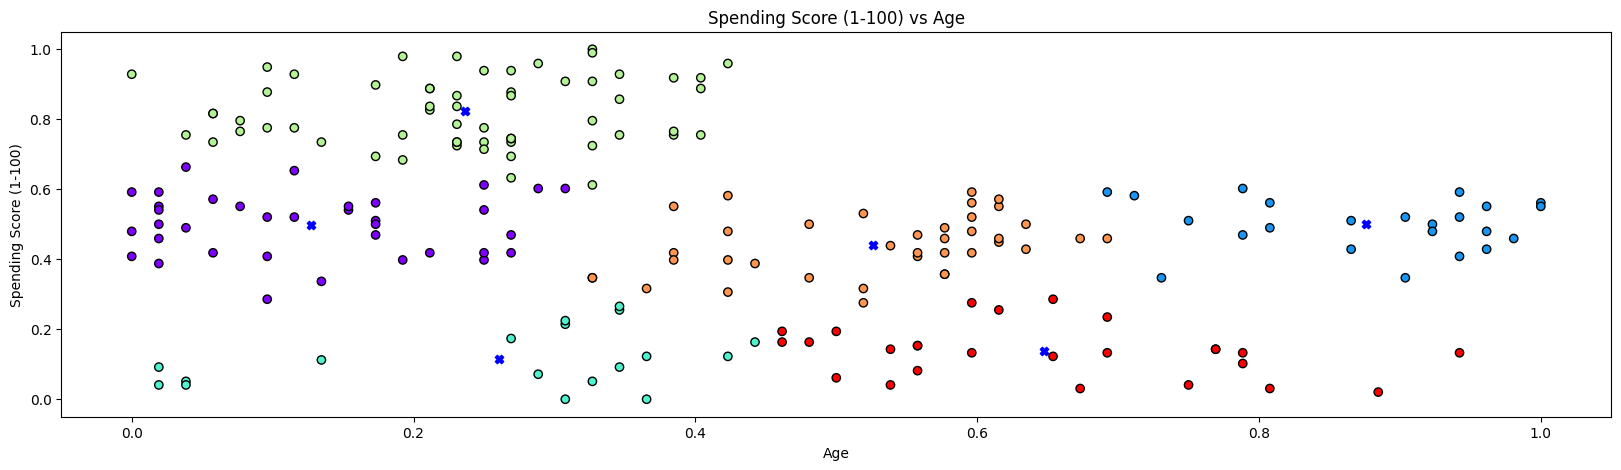

In [34]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

##Annual Income (k$) - Spending Score (1-100)

In [35]:
m1 = df1[['Annual Income (k$)', 'Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Annual Income (k$)', 'Spending Score (1-100)']].values # Normalized Dataset

###Original Dataset
####Elbow Method & Silhouette Score Method

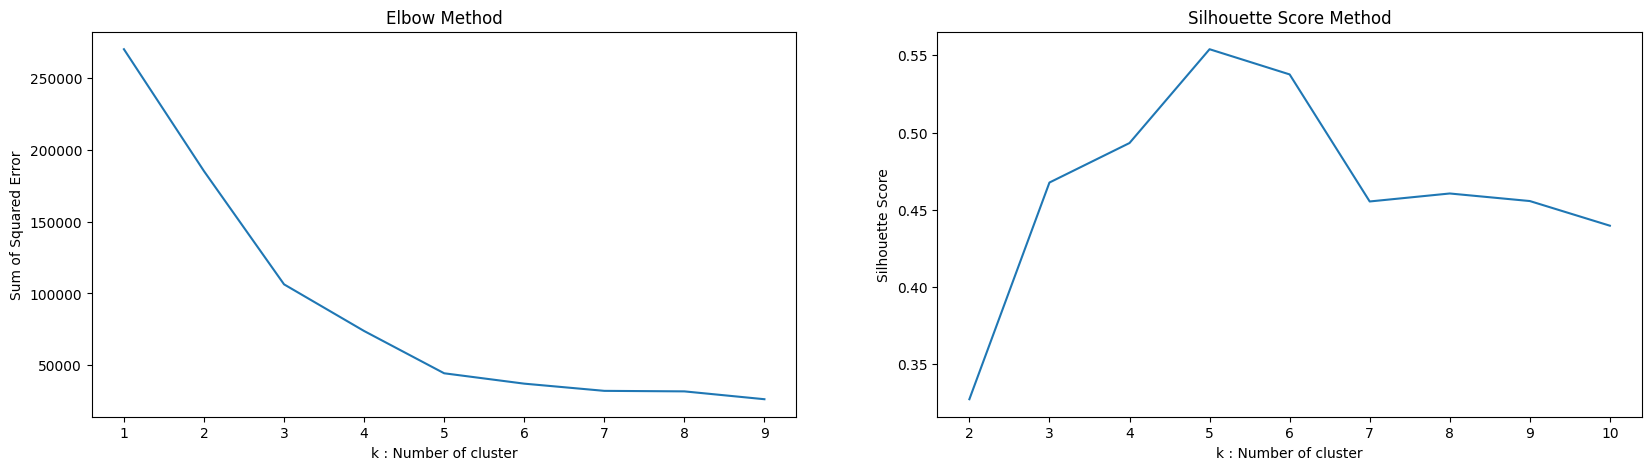

In [36]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

k: Clusters = 5 선택

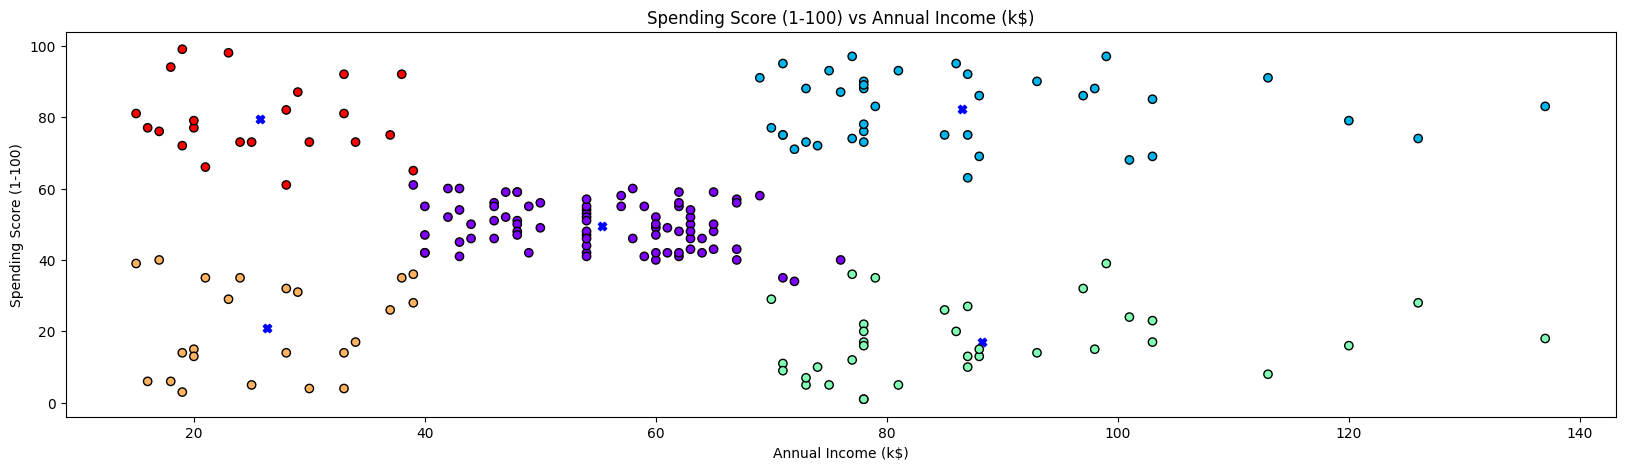

In [37]:
model = KMeans(n_clusters = 5,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

###Normalized Dataset
####Elbow Method & Silhouette Score Method

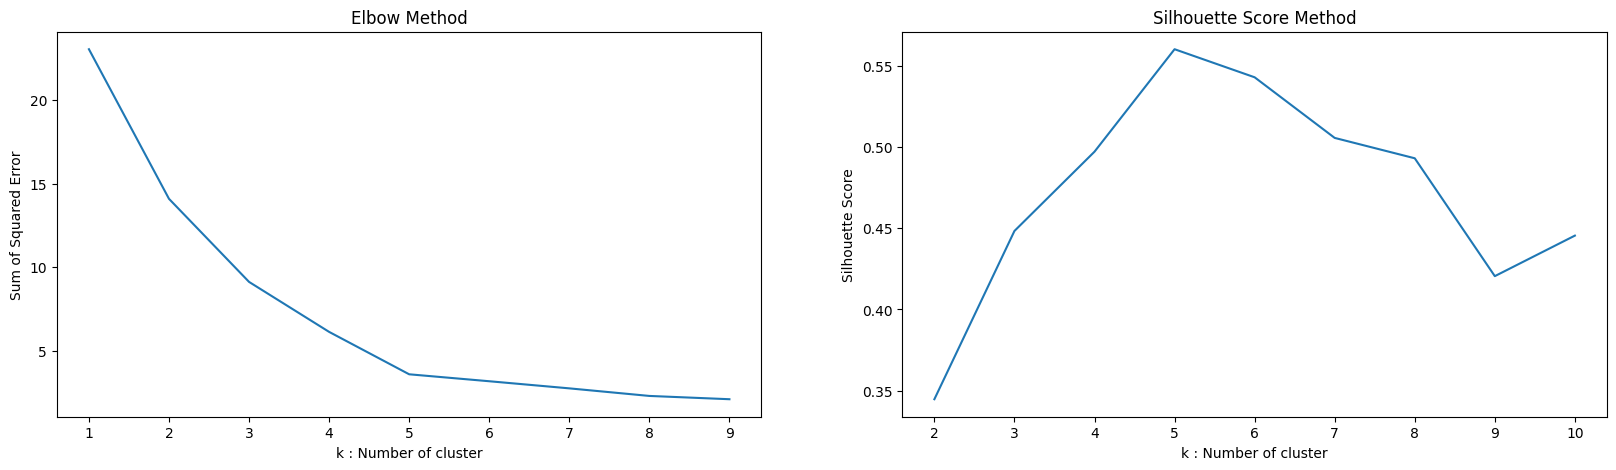

In [38]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

k: Clusters = 5 선택

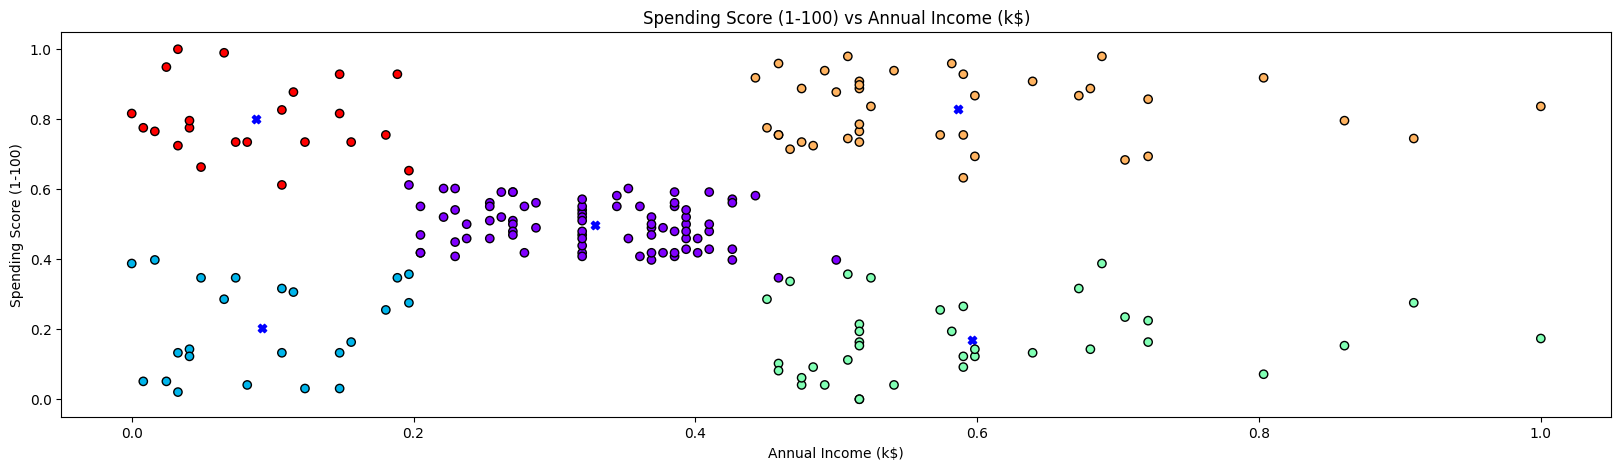

In [39]:
model = KMeans(n_clusters = 5,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

##Age - Annual Income (k$) - Spending Score (1-100)

In [40]:
m1 = df1[['Age','Annual Income (k$)','Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Age','Annual Income (k$)','Spending Score (1-100)']].values # Normalized Dataset

###Original Dataset
####Elbow Method & Silhouette Score Method

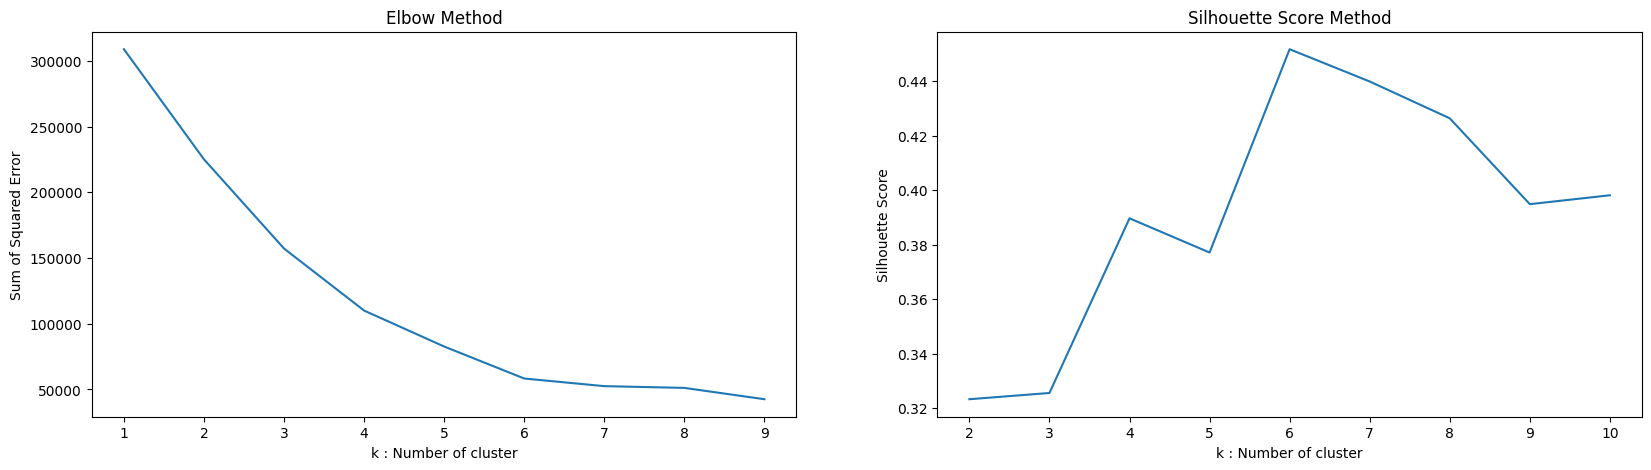

In [41]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

k: Clusters = 6 선택

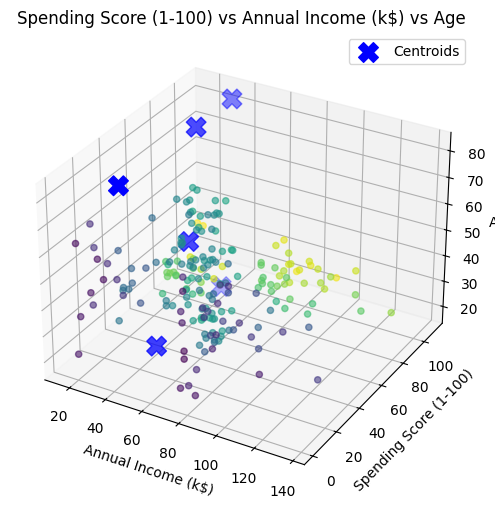

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
# 데이터프레임(df1, m1)은 이미 정의되어 있다고 가정합니다.

model = KMeans(n_clusters=6, max_iter=1000, random_state=42)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

fig = plt.figure(figsize=(8, 6))

# [핵심 수정 부분] 최신 버전에 맞게 3D 축 생성
ax = fig.add_subplot(111, projection='3d')

x = np.array(df1['Annual Income (k$)'])
y = np.array(df1['Spending Score (1-100)'])
z = np.array(df1['Age'])

# 군집 중심점 표시 (파란색 X 마커, 크기 확대)
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], marker="X", color='b', s=200, label='Centroids')

# 원본 데이터 산점도 표시
ax.scatter(x, y, z, c=y, cmap='viridis', alpha=0.6)

plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
plt.legend()
plt.show()

###Normalized Dataset
####Elbow Method & Silhouette Score Method

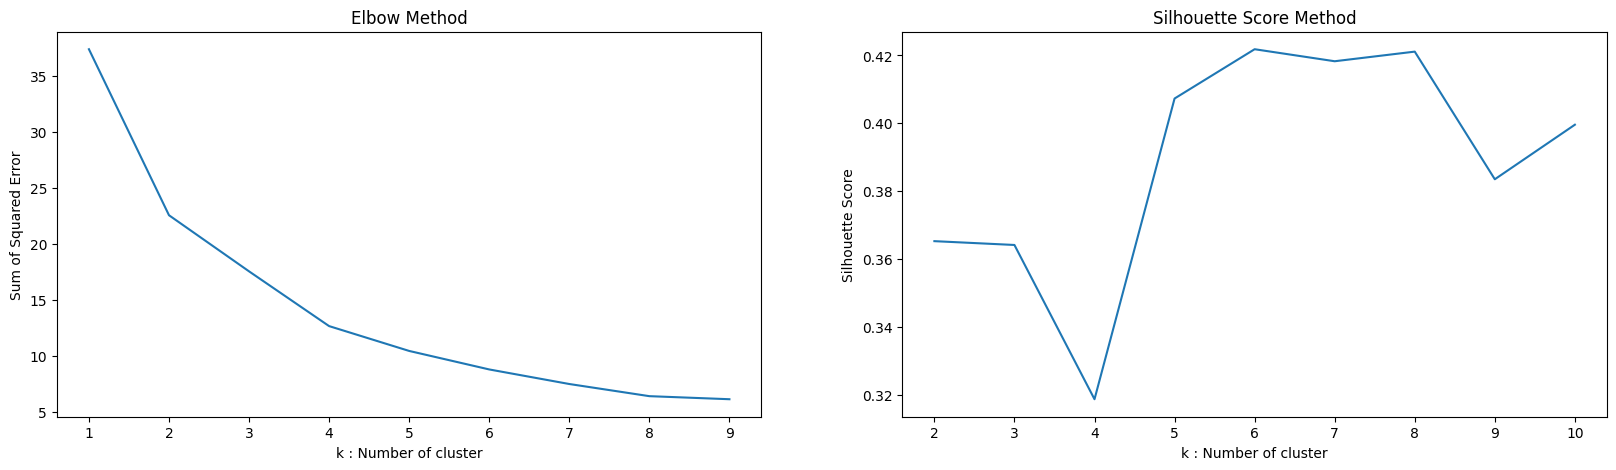

In [43]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

k: Clusters = 6 선택

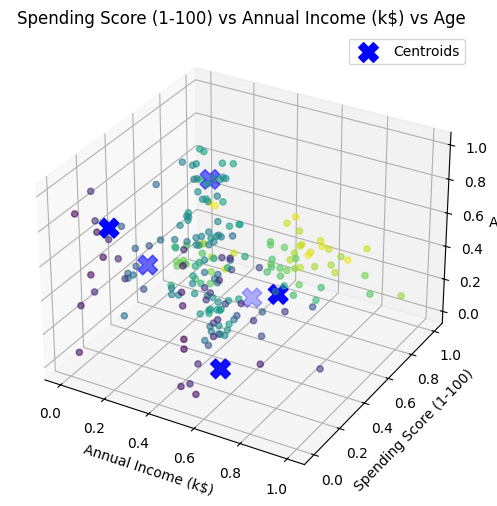

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
# 데이터프레임(df2, m2)은 이미 정의되어 있다고 가정합니다.

model = KMeans(n_clusters=6, max_iter=1000, random_state=42) # 결과 재현을 위해 random_state 추가 추천
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

fig = plt.figure(figsize=(8, 6)) # 그래프 크기를 지정해주면 더 깔끔하게 보입니다.

# [핵심 수정 부분] 구버전의 Axes3D(fig) 대신 아래 코드를 사용하세요!
ax = fig.add_subplot(111, projection='3d')

x = np.array(df2['Annual Income (k$)'])
y = np.array(df2['Spending Score (1-100)'])
z = np.array(df2['Age'])

# 군집 중심점 표시 (파란색 X 마커)
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], marker="X", color='b', s=200, label='Centroids')

# 원본 데이터 산점도 표시 (y값에 따라 색상 다르게)
ax.scatter(x, y, z, c=y, cmap='viridis', alpha=0.6)

plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
plt.legend()
plt.show()

# Conclusion

* 본 데이터셋은 **비지도학습을 이해하고 적용하는 데 적합한 사례**이며, 고객 세분화를 통해 매출 증대 전략 수립에 활용할 수 있음.
* 비지도학습에서는 **EDA(탐색적 데이터 분석)가 숨겨진 패턴과 인사이트를 발견하는 데 중요한 역할을 함**.
* 다만 데이터 규모와 변수 수가 증가할수록 **시각화 기반 분석의 복잡성이 높아질 수 있음**.
* K-Means 클러스터링에서는 **최적의 군집 수(k)를 선택하는 것이 핵심이며**, 엘보우 기법과 실루엣 점수 등의 통계적 방법을 활용함.
* 본 사례에서는 **원본 데이터와 정규화된 데이터로 학습한 모델 간 성능 차이가 크지 않음**.
* 최종적으로 고객을 여러 그룹으로 세분화하여 **고객 특성에 맞는 맞춤형 마케팅 및 비즈니스 전략 수립이 가능함**.
